# Bank Customer & Card Member Behavior — Exploratory Data Analysis

## Project objective

To perform an end-to-end **Exploratory Data Analysis (EDA)** on a bank customer churn dataset.

The goal is to understand:

- Customer demographics and financial characteristics
- Banking and card usage behavior
- Customer satisfaction and complaints
- Differences between retained and churned customers
- Geographic and card-type patterns
- Potential customer segments and business opportunities

## 1. Import libraries

We will use:

- **Pandas** — data loading and manipulation
- **NumPy** — numerical operations
- **Matplotlib** — basic visualization
- **Seaborn** — statistical visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the dataset

In [2]:
FILE_PATH = "Customer-Churn-Records.csv"

df = pd.read_csv(FILE_PATH)

print(f"Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 10,000
Columns: 18


## 3. First look at the data

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [4]:
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,0,1,DIAMOND,300
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,0,5,PLATINUM,771
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,1,3,SILVER,564
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,1,2,GOLD,339
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0,0,3,DIAMOND,911


In [5]:
df.sample(5, random_state=42)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
6252,6253,15687492,Anderson,596,Germany,Male,32,3,96709.07,2,0,0,41788.37,0,0,1,GOLD,709
4684,4685,15736963,Herring,623,France,Male,43,1,0.00,2,1,1,146379.30,0,0,2,SILVER,508
1731,1732,15721730,Amechi,601,Spain,Female,44,4,0.00,2,1,0,58561.31,0,0,1,GOLD,281
4742,4743,15762134,Liang,506,Germany,Male,59,8,119152.10,2,1,1,170679.74,0,0,2,SILVER,979
4521,4522,15648898,Chuang,560,Spain,Female,27,7,124995.98,1,1,1,114669.79,0,0,5,SILVER,457


## 4. Understand the structure

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  str    
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  str    
 5   Gender              10000 non-null  str    
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card Type       

In [7]:
df.dtypes.to_frame("Data Type")

,Data Type
RowNumber,int64
CustomerId,int64
Surname,str
CreditScore,int64
Geography,str
Gender,str
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64


In [8]:
print("Shape:", df.shape)

print("\nColumns:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i:>2}. {col}")

Shape: (10000, 18)

Columns:
 1. RowNumber
 2. CustomerId
 3. Surname
 4. CreditScore
 5. Geography
 6. Gender
 7. Age
 8. Tenure
 9. Balance
10. NumOfProducts
11. HasCrCard
12. IsActiveMember
13. EstimatedSalary
14. Exited
15. Complain
16. Satisfaction Score
17. Card Type
18. Point Earned


## 5. Data dictionary

| Column | Meaning |
|---|---|
| `RowNumber` | Row/index identifier |
| `CustomerId` | Customer identifier |
| `Surname` | Customer surname |
| `CreditScore` | Customer credit score |
| `Geography` | Customer country |
| `Gender` | Customer gender |
| `Age` | Customer age |
| `Tenure` | Years with the bank |
| `Balance` | Account balance |
| `NumOfProducts` | Number of bank products held |
| `HasCrCard` | Whether the customer has a credit card |
| `IsActiveMember` | Whether the customer is an active member |
| `EstimatedSalary` | Estimated customer salary |
| `Exited` | Churn indicator: 1 = exited, 0 = retained |
| `Complain` | Whether the customer made a complaint |
| `Satisfaction Score` | Satisfaction score |
| `Card Type` | Customer card type |
| `Point Earned` | Loyalty/reward points earned |

`RowNumber`, `CustomerId`, and `Surname` are identifiers rather than useful behavioral features, so we will not use them for analytical relationships.


## 6. Data quality check

In [39]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Missing %": missing_pct
})

missing_table[missing_table["Missing Values"] > 0]

,Missing Values,Missing %


In [40]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [11]:
unique_counts = df.nunique().sort_values()
unique_counts.to_frame("Unique Values")

,Unique Values
Gender,2
Complain,2
HasCrCard,2
IsActiveMember,2
Exited,2
Geography,3
NumOfProducts,4
Card Type,4
Satisfaction Score,5
Tenure,11


### Data quality conclusion

The checks above help us decide whether cleaning is required.

- Missing values should be investigated before analysis.
- Duplicate rows should be checked.
- Identifier columns should not be treated as business features.
- Binary fields such as `Exited`, `Complain`, `HasCrCard`, and `IsActiveMember` should be interpreted correctly.

## 7. Prepare a clean analysis dataset

In [12]:
analysis_df = df.drop(columns=["RowNumber", "CustomerId", "Surname"]).copy()

analysis_df["Exited_Label"] = analysis_df["Exited"].map({0: "Retained", 1: "Exited"})
analysis_df["Active_Label"] = analysis_df["IsActiveMember"].map({0: "Inactive", 1: "Active"})
analysis_df["CreditCard_Label"] = analysis_df["HasCrCard"].map({0: "No Card", 1: "Has Card"})
analysis_df["Complaint_Label"] = analysis_df["Complain"].map({0: "No Complaint", 1: "Complaint"})

analysis_df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned,Exited_Label,Active_Label,CreditCard_Label,Complaint_Label
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464,Exited,Active,Has Card,Complaint
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456,Retained,Active,No Card,Complaint
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377,Exited,Inactive,Has Card,Complaint
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350,Retained,Inactive,No Card,No Complaint
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425,Retained,Active,Has Card,No Complaint


## 8. Descriptive statistics

In [13]:
analysis_df.describe().T

,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
Age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
Tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
Balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
NumOfProducts,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
HasCrCard,10000.0,0.705500,0.455840,0.00,0.00,1.000,1.0000,1.00
IsActiveMember,10000.0,0.515100,0.499797,0.00,0.00,1.000,1.0000,1.00
EstimatedSalary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48
Exited,10000.0,0.203800,0.402842,0.00,0.00,0.000,0.0000,1.00
Complain,10000.0,0.204400,0.403283,0.00,0.00,0.000,0.0000,1.00


In [14]:
numeric_cols = analysis_df.select_dtypes(include=np.number).columns.tolist()
analysis_df[numeric_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.53,96.65,350.00,584.00,652.00,718.00,850.00
Age,10000.0,38.92,10.49,18.00,32.00,37.00,44.00,92.00
Tenure,10000.0,5.01,2.89,0.00,3.00,5.00,7.00,10.00
Balance,10000.0,76485.89,62397.41,0.00,0.00,97198.54,127644.24,250898.09
NumOfProducts,10000.0,1.53,0.58,1.00,1.00,1.00,2.00,4.00
HasCrCard,10000.0,0.71,0.46,0.00,0.00,1.00,1.00,1.00
IsActiveMember,10000.0,0.52,0.50,0.00,0.00,1.00,1.00,1.00
EstimatedSalary,10000.0,100090.24,57510.49,11.58,51002.11,100193.92,149388.25,199992.48
Exited,10000.0,0.20,0.40,0.00,0.00,0.00,0.00,1.00
Complain,10000.0,0.20,0.40,0.00,0.00,0.00,0.00,1.00


## 9. Categorical variable distributions

In [15]:
categorical_cols = ["Geography", "Gender", "Card Type"]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(analysis_df[col].value_counts())
    print("\nPercentage:")
    print((analysis_df[col].value_counts(normalize=True) * 100).round(2))


--- Geography ---
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Percentage:
Geography
France     50.14
Germany    25.09
Spain      24.77
Name: proportion, dtype: float64

--- Gender ---
Gender
Male      5457
Female    4543
Name: count, dtype: int64

Percentage:
Gender
Male      54.57
Female    45.43
Name: proportion, dtype: float64

--- Card Type ---
Card Type
DIAMOND     2507
GOLD        2502
SILVER      2496
PLATINUM    2495
Name: count, dtype: int64

Percentage:
Card Type
DIAMOND     25.07
GOLD        25.02
SILVER      24.96
PLATINUM    24.95
Name: proportion, dtype: float64


## 10. Target variable — customer churn

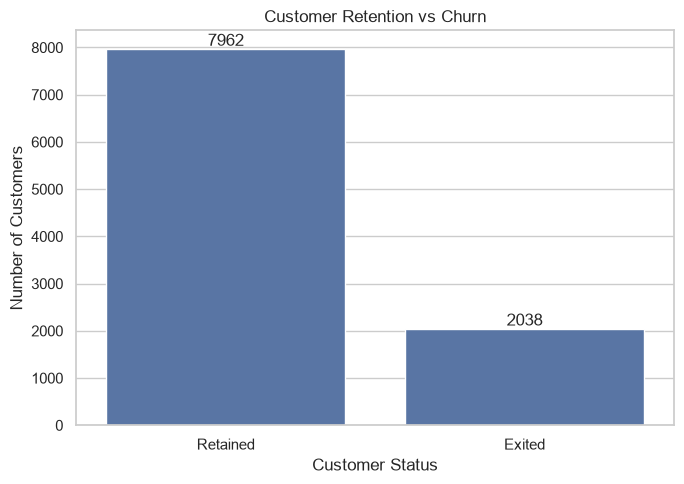

Overall churn rate: 20.38%


In [16]:
churn_counts = analysis_df["Exited_Label"].value_counts()

plt.figure(figsize=(7, 5))
ax = sns.countplot(data=analysis_df, x="Exited_Label", order=["Retained", "Exited"])
plt.title("Customer Retention vs Churn")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

churn_rate = analysis_df["Exited"].mean() * 100
print(f"Overall churn rate: {churn_rate:.2f}%")

### Question

**How large is the churn problem?**

The churn rate is one of the most important starting KPIs. Later, we will break it down by customer characteristics to identify segments with higher or lower churn.

## 11. Univariate analysis — numerical variables

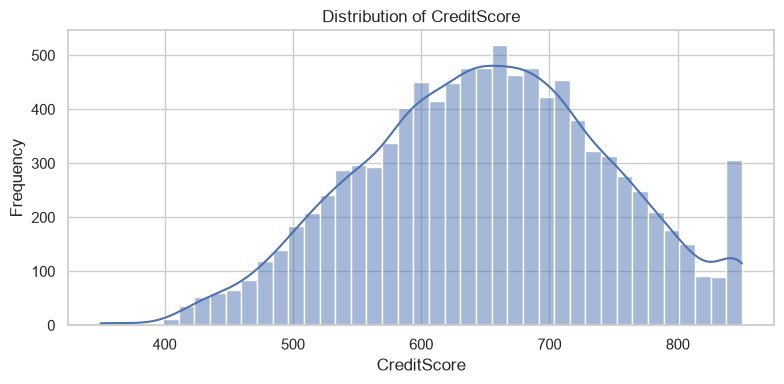

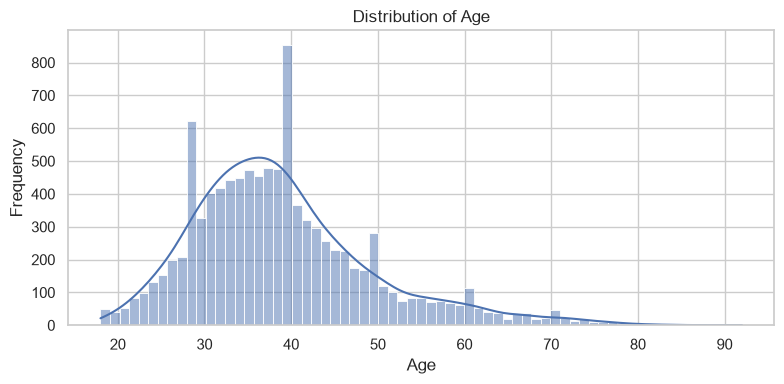

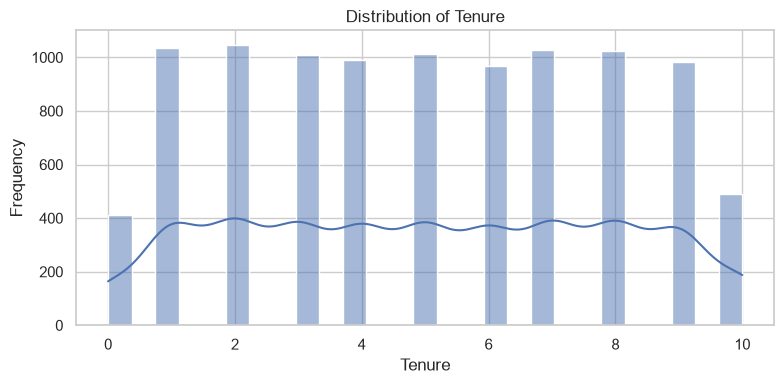

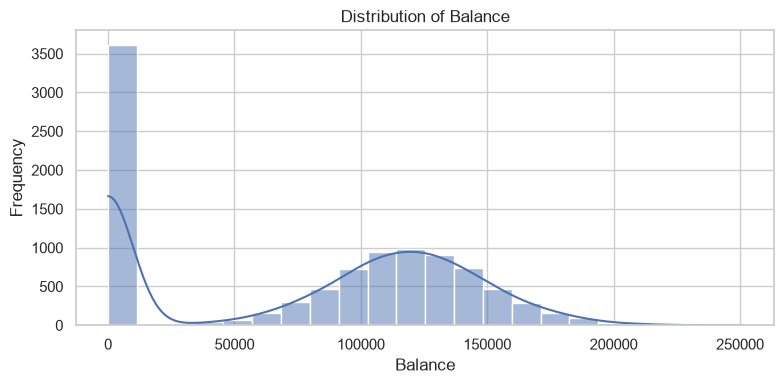

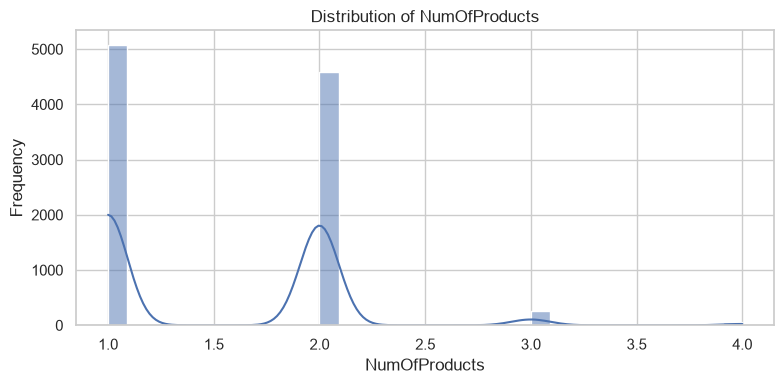

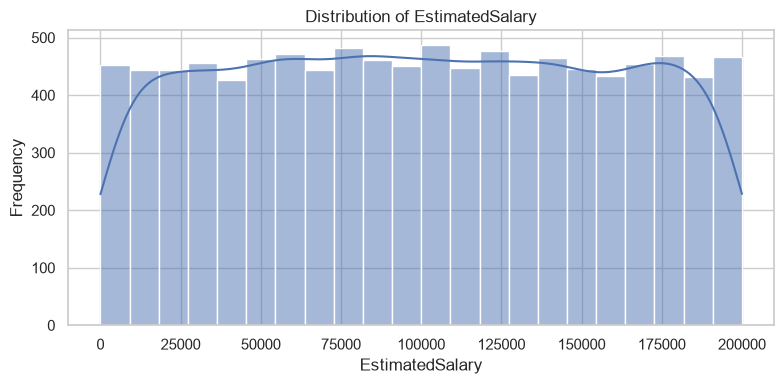

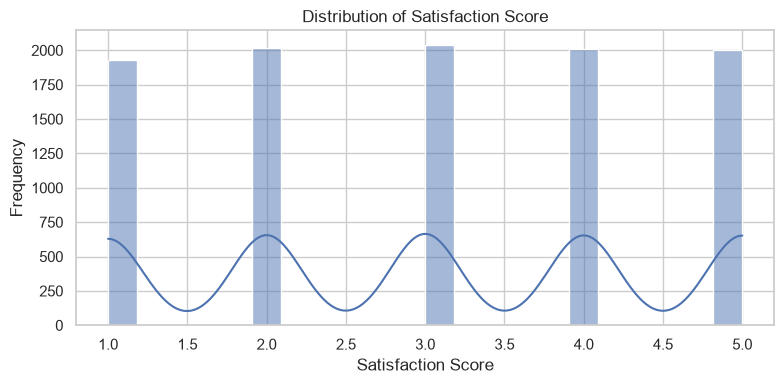

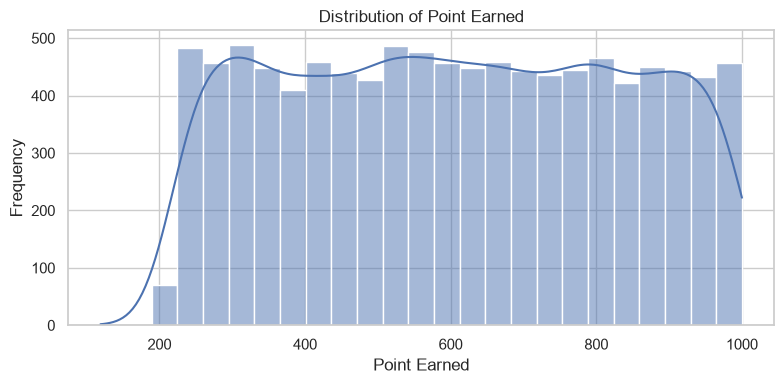

In [17]:
numeric_to_plot = [
    "CreditScore", "Age", "Tenure", "Balance",
    "NumOfProducts", "EstimatedSalary",
    "Satisfaction Score", "Point Earned"
]

for col in numeric_to_plot:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=analysis_df, x=col, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

### What to look for

For every distribution, ask:

- Is it roughly symmetric or skewed?
- Are there unusual/extreme values?
- Is the variable concentrated in a small range?
- Could the distribution affect customer segmentation?

Do not automatically remove outliers. In banking data, an extreme value may represent a legitimate high-value customer.

## 12. Customer demographics

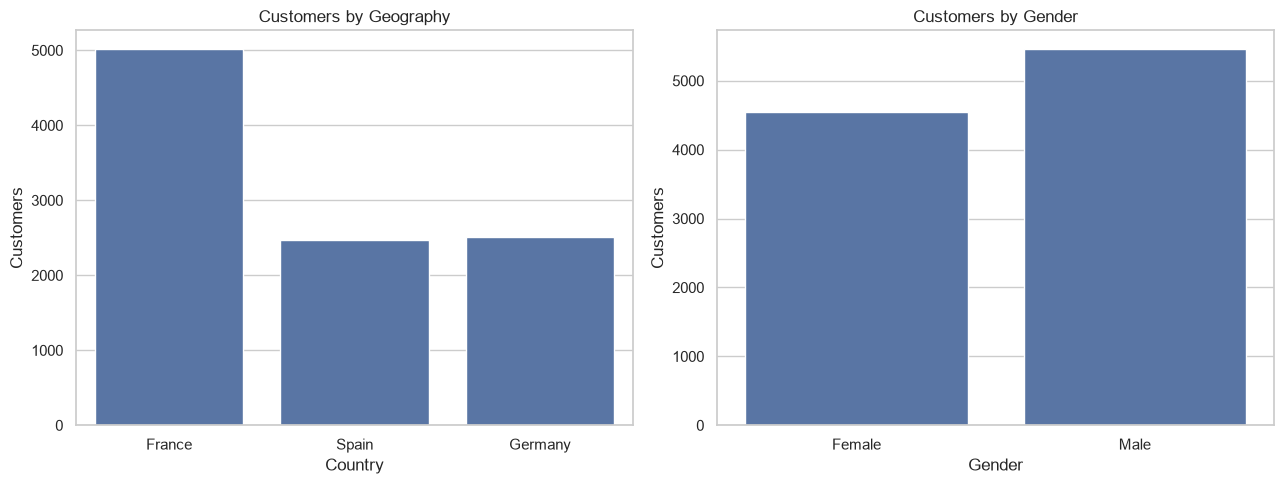

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(data=analysis_df, x="Geography", ax=axes[0])
axes[0].set_title("Customers by Geography")
axes[0].set_xlabel("Country")
axes[0].set_ylabel("Customers")

sns.countplot(data=analysis_df, x="Gender", ax=axes[1])
axes[1].set_title("Customers by Gender")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Customers")

plt.tight_layout()
plt.show()

## 13. Churn by geography

Geography
Germany    32.44
Spain      16.67
France     16.17
Name: Exited, dtype: float64


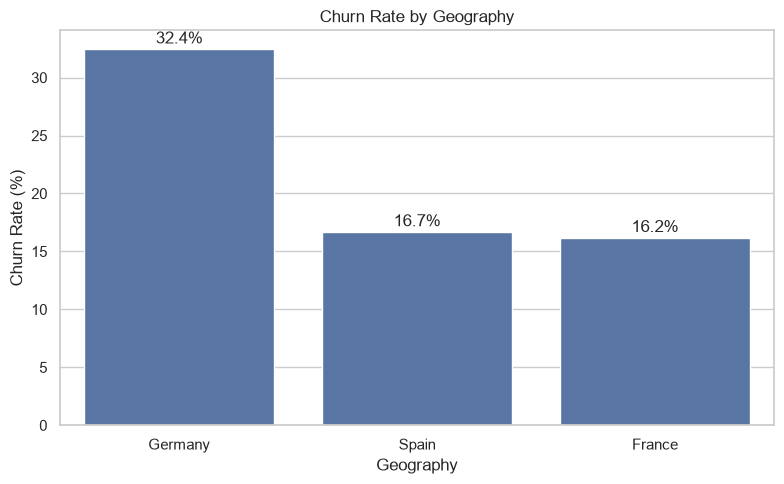

In [19]:
geo_churn = (
    analysis_df.groupby("Geography")["Exited"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(geo_churn.round(2))

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=geo_churn.index, y=geo_churn.values)
plt.title("Churn Rate by Geography")
plt.xlabel("Geography")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(geo_churn.values):
    ax.text(i, value + 0.5, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.show()

## 14. Churn by gender

Gender
Female    25.07
Male      16.47
Name: Exited, dtype: float64


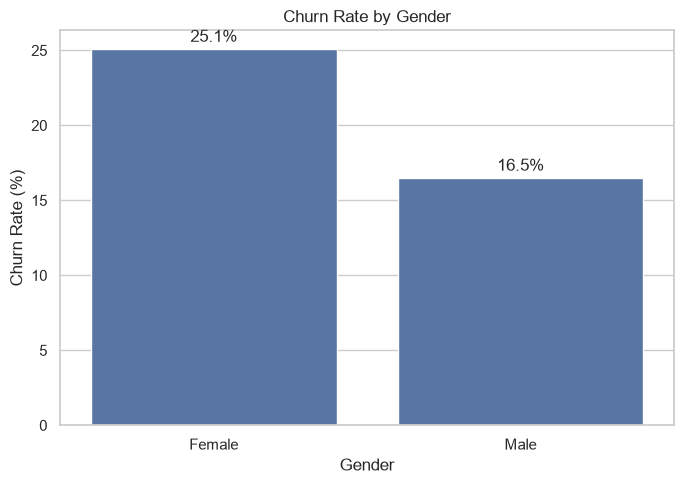

In [20]:
gender_churn = (
    analysis_df.groupby("Gender")["Exited"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(gender_churn.round(2))

plt.figure(figsize=(7, 5))
ax = sns.barplot(x=gender_churn.index, y=gender_churn.values)
plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(gender_churn.values):
    ax.text(i, value + 0.5, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.show()

## 15. Churn by age

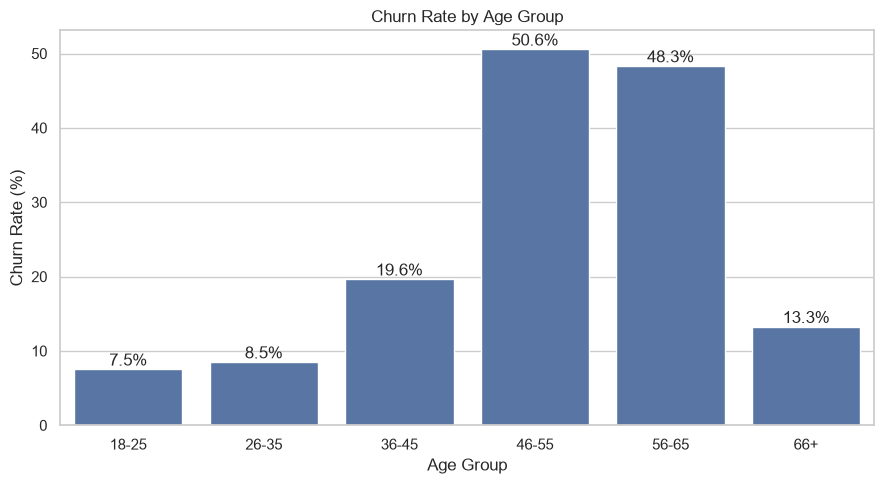

Age_Group
18-25     7.53
26-35     8.50
36-45    19.65
46-55    50.57
56-65    48.32
66+      13.26
Name: Exited, dtype: float64


In [21]:
bins = [17, 25, 35, 45, 55, 65, 100]
labels = ["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]

analysis_df["Age_Group"] = pd.cut(
    analysis_df["Age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

age_churn = (
    analysis_df.groupby("Age_Group", observed=False)["Exited"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(9, 5))
ax = sns.barplot(x=age_churn.index, y=age_churn.values)
plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(age_churn.values):
    ax.text(i, value + 0.5, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.show()

print(age_churn.round(2))

## 16. Credit score and churn

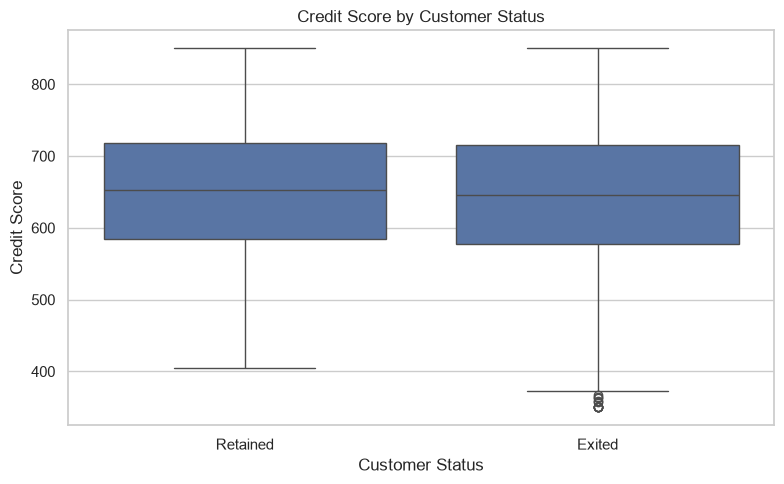

                mean  median  min  max
Exited_Label                          
Exited        645.41   646.0  350  850
Retained      651.84   653.0  405  850


In [22]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=analysis_df, x="Exited_Label", y="CreditScore", order=["Retained", "Exited"])
plt.title("Credit Score by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Credit Score")
plt.tight_layout()
plt.show()

print(
    analysis_df.groupby("Exited_Label")["CreditScore"]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)

## 17. Account balance and churn

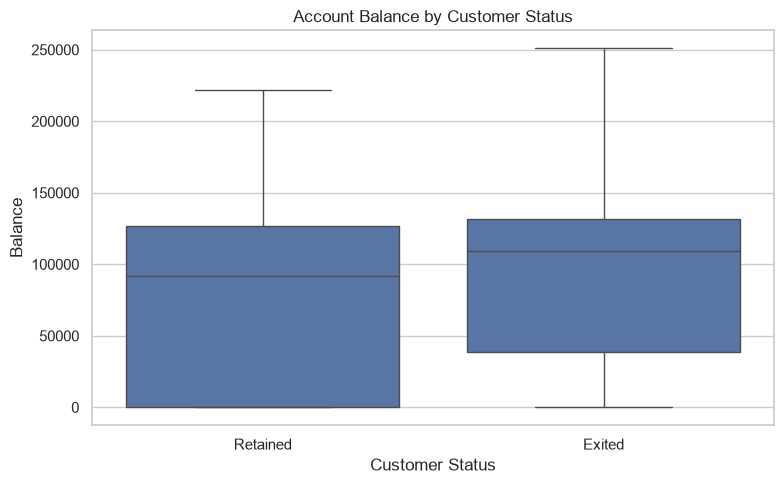

                  mean     median
Exited_Label                     
Exited        91109.48  109344.23
Retained      72742.75   92063.06


In [23]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=analysis_df, x="Exited_Label", y="Balance", order=["Retained", "Exited"])
plt.title("Account Balance by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Balance")
plt.tight_layout()
plt.show()

print(
    analysis_df.groupby("Exited_Label")["Balance"]
    .agg(["mean", "median"])
    .round(2)
)

## 18. Number of products and churn

               count  churn_rate_%
NumOfProducts                     
1               5084         27.71
2               4590          7.60
3                266         82.71
4                 60        100.00


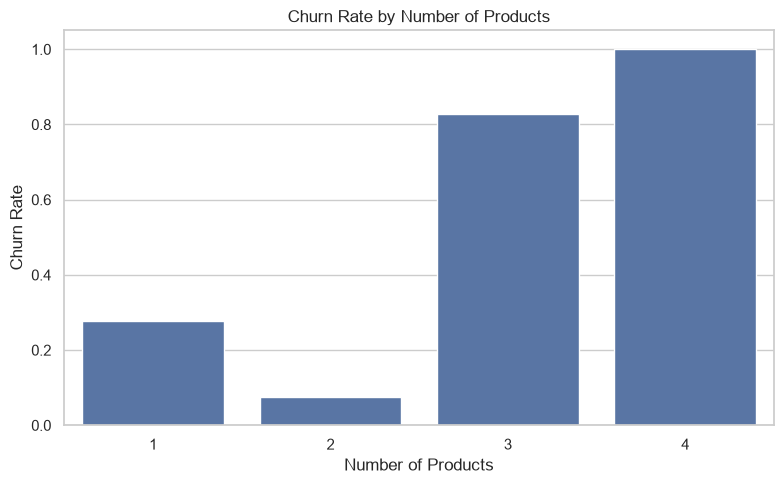

In [24]:
product_churn = (
    analysis_df.groupby("NumOfProducts")["Exited"]
    .agg(["count", "mean"])
)

product_churn["churn_rate_%"] = product_churn["mean"] * 100
product_churn = product_churn.drop(columns="mean")

print(product_churn.round(2))

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=analysis_df,
    x="NumOfProducts",
    y="Exited",
    estimator=np.mean,
    errorbar=None
)
plt.title("Churn Rate by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate")

plt.tight_layout()
plt.show()

## 19. Customer activity and churn

Active_Label
Inactive    26.87
Active      14.27
Name: Exited, dtype: float64


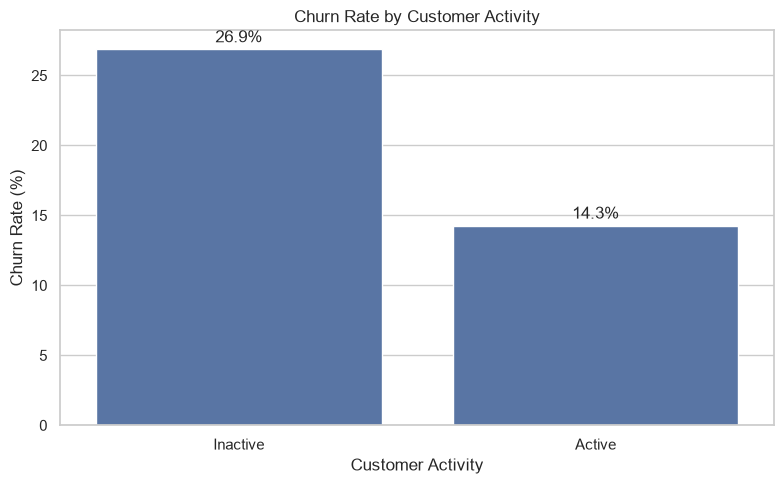

In [25]:
activity_churn = (
    analysis_df.groupby("Active_Label")["Exited"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(activity_churn.round(2))

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=activity_churn.index, y=activity_churn.values)
plt.title("Churn Rate by Customer Activity")
plt.xlabel("Customer Activity")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(activity_churn.values):
    ax.text(i, value + 0.5, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.show()

## 20. Credit card ownership and churn

CreditCard_Label
No Card     20.81
Has Card    20.20
Name: Exited, dtype: float64


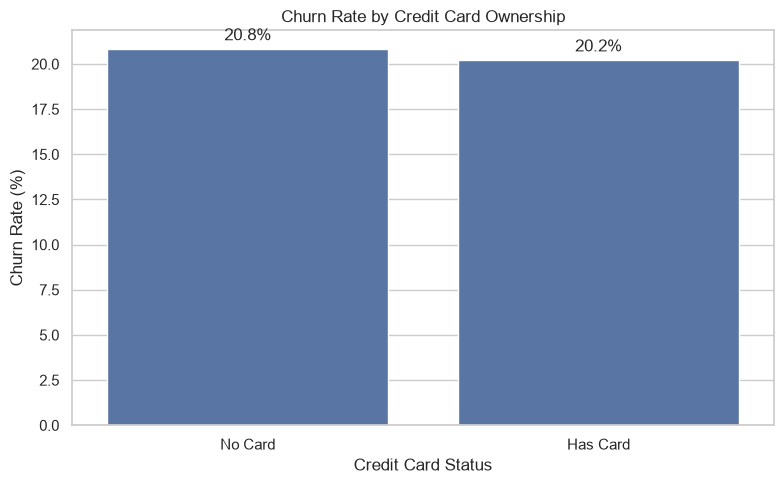

In [26]:
card_churn = (
    analysis_df.groupby("CreditCard_Label")["Exited"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(card_churn.round(2))

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=card_churn.index, y=card_churn.values)
plt.title("Churn Rate by Credit Card Ownership")
plt.xlabel("Credit Card Status")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(card_churn.values):
    ax.text(i, value + 0.5, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.show()

## 21. Card type analysis

In [27]:
card_type_summary = (
    analysis_df.groupby("Card Type")
    .agg(
        Customers=("Exited", "size"),
        Churn_Rate=("Exited", "mean"),
        Avg_Points=("Point Earned", "mean"),
        Avg_Satisfaction=("Satisfaction Score", "mean")
    )
)

card_type_summary["Churn_Rate"] *= 100

card_type_summary.round(2)

,Customers,Churn_Rate,Avg_Points,Avg_Satisfaction
Card Type,,,,
DIAMOND,2507,21.78,605.98,2.99
GOLD,2502,19.26,607.24,3.04
PLATINUM,2495,20.36,608.84,3.01
SILVER,2496,20.11,604.00,3.01


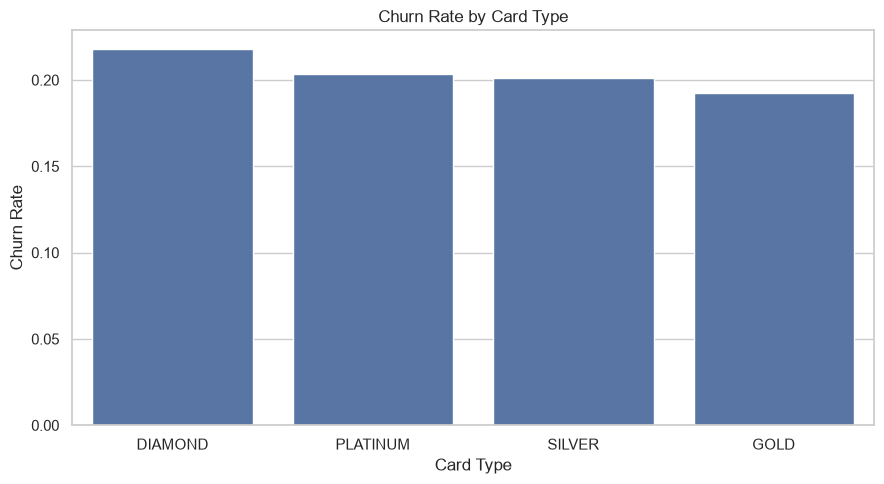

In [28]:
plt.figure(figsize=(9, 5))
card_order = card_type_summary["Churn_Rate"].sort_values(ascending=False).index

ax = sns.barplot(
    data=analysis_df,
    x="Card Type",
    y="Exited",
    order=card_order,
    estimator=np.mean,
    errorbar=None
)

plt.title("Churn Rate by Card Type")
plt.xlabel("Card Type")
plt.ylabel("Churn Rate")

plt.tight_layout()
plt.show()

## 22. Satisfaction score and churn

Satisfaction Score
1    20.03
2    21.80
3    19.64
4    20.62
5    19.81
Name: Exited, dtype: float64


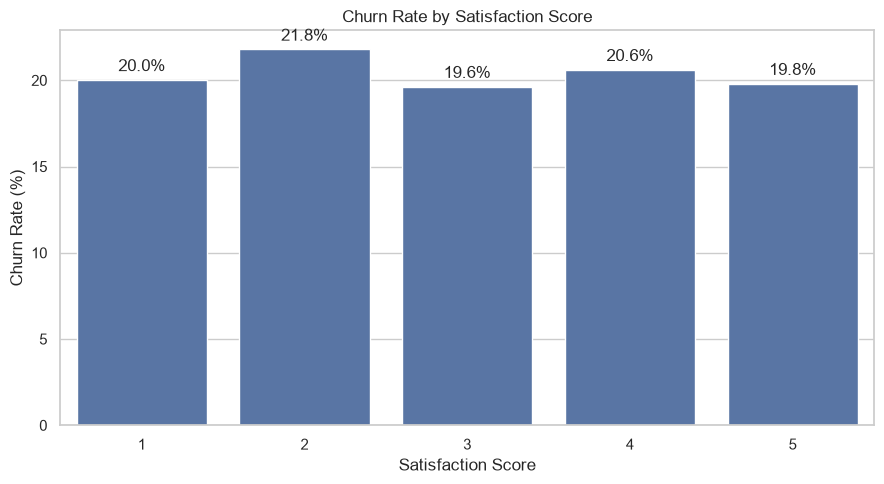

In [29]:
satisfaction_churn = (
    analysis_df.groupby("Satisfaction Score")["Exited"]
    .mean()
    .mul(100)
)

print(satisfaction_churn.round(2))

plt.figure(figsize=(9, 5))
ax = sns.barplot(x=satisfaction_churn.index, y=satisfaction_churn.values)
plt.title("Churn Rate by Satisfaction Score")
plt.xlabel("Satisfaction Score")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(satisfaction_churn.values):
    ax.text(i, value + 0.5, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.show()

## 23. Complaints and churn

Complaint_Label
Complaint       99.51
No Complaint     0.05
Name: Exited, dtype: float64


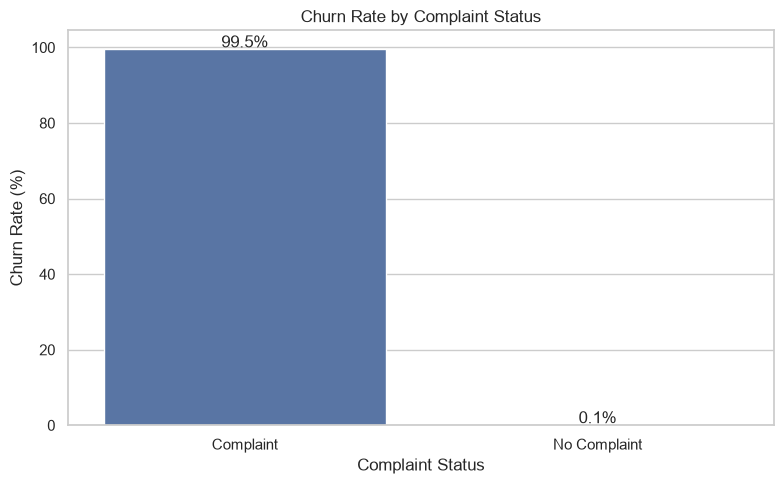

In [30]:
complaint_churn = (
    analysis_df.groupby("Complaint_Label")["Exited"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(complaint_churn.round(2))

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=complaint_churn.index, y=complaint_churn.values)
plt.title("Churn Rate by Complaint Status")
plt.xlabel("Complaint Status")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(complaint_churn.values):
    ax.text(i, value + 0.5, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.show()

## 24. Active customers and complaints

In [31]:
active_complaint = pd.crosstab(
    analysis_df["Active_Label"],
    analysis_df["Complaint_Label"],
    normalize="index"
) * 100

active_complaint.round(2)

Complaint_Label,Complaint,No Complaint
Active_Label,,
Active,14.39,85.61
Inactive,26.87,73.13


## 25. Correlation analysis

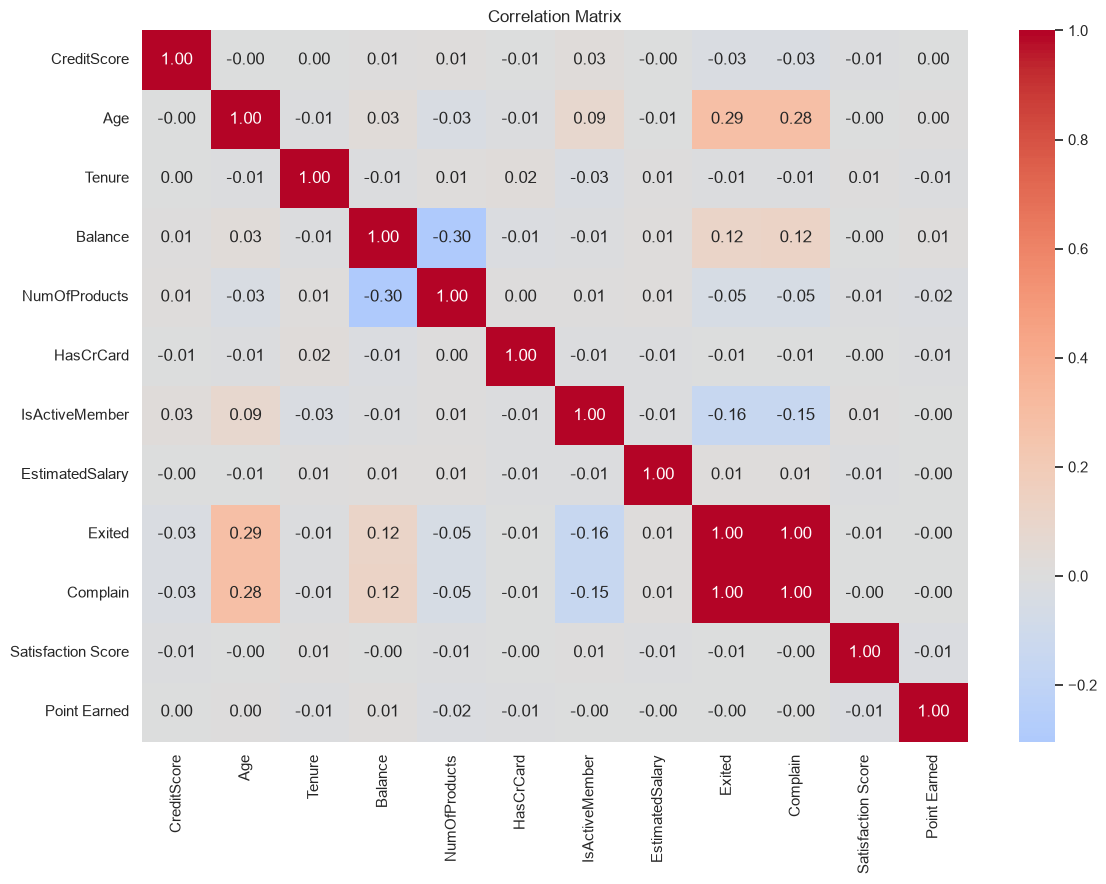

In [32]:
corr_cols = [
    "CreditScore", "Age", "Tenure", "Balance",
    "NumOfProducts", "HasCrCard", "IsActiveMember",
    "EstimatedSalary", "Exited", "Complain",
    "Satisfaction Score", "Point Earned"
]

corr = analysis_df[corr_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

- Values close to **+1** indicate a strong positive linear relationship.
- Values close to **-1** indicate a strong negative linear relationship.
- Values close to **0** indicate little linear relationship.



## 26. Compare important customer metrics by churn status

In [33]:
key_metrics = [
    "CreditScore", "Age", "Balance", "NumOfProducts",
    "EstimatedSalary", "Satisfaction Score", "Point Earned"
]

group_summary = analysis_df.groupby("Exited_Label")[key_metrics].mean().T
group_summary.round(2)

Exited_Label,Exited,Retained
CreditScore,645.41,651.84
Age,44.84,37.41
Balance,91109.48,72742.75
NumOfProducts,1.48,1.54
EstimatedSalary,101509.91,99726.85
Satisfaction Score,3.00,3.02
Point Earned,604.45,607.04


## 27. Build a simple customer-risk segment for exploration

In [34]:
risk_conditions = (
    (analysis_df["IsActiveMember"] == 0) &
    (analysis_df["Complain"] == 1) &
    (analysis_df["Satisfaction Score"] <= 2)
)

analysis_df["Exploratory_Risk_Flag"] = np.where(
    risk_conditions, "Potentially At Risk", "Other"
)

risk_summary = (
    analysis_df.groupby("Exploratory_Risk_Flag")["Exited"]
    .agg(["count", "mean"])
)

risk_summary["churn_rate_%"] = risk_summary["mean"] * 100
risk_summary.drop(columns="mean").round(2)

,count,churn_rate_%
Exploratory_Risk_Flag,,
Other,9473,15.96
Potentially At Risk,527,99.81


## 28. Identify high-value customer candidates

In [35]:
balance_threshold = analysis_df["Balance"].quantile(0.75)

high_value = analysis_df[analysis_df["Balance"] >= balance_threshold]

print(f"75th percentile balance threshold: {balance_threshold:,.2f}")
print(f"High-balance customers: {len(high_value):,}")
print(f"High-balance customer churn rate: {high_value['Exited'].mean() * 100:.2f}%")

high_value.groupby("Card Type").agg(
    Customers=("Exited", "size"),
    Churn_Rate=("Exited", lambda x: x.mean() * 100),
    Avg_Points=("Point Earned", "mean")
).round(2)

75th percentile balance threshold: 127,644.24
High-balance customers: 2,500
High-balance customer churn rate: 23.68%


,Customers,Churn_Rate,Avg_Points
Card Type,,,
DIAMOND,640,24.06,605.91
GOLD,617,21.56,605.87
PLATINUM,617,22.69,611.12
SILVER,626,26.36,607.99


## 29. Geographic + activity segmentation

In [36]:
geo_activity = (
    analysis_df.groupby(["Geography", "Active_Label"])["Exited"]
    .mean()
    .mul(100)
    .reset_index(name="Churn_Rate")
)

geo_activity.round(2)

,Geography,Active_Label,Churn_Rate
0,France,Active,11.50
1,France,Inactive,21.17
2,Germany,Active,23.72
3,Germany,Inactive,41.08
4,Spain,Active,10.75
5,Spain,Inactive,23.35


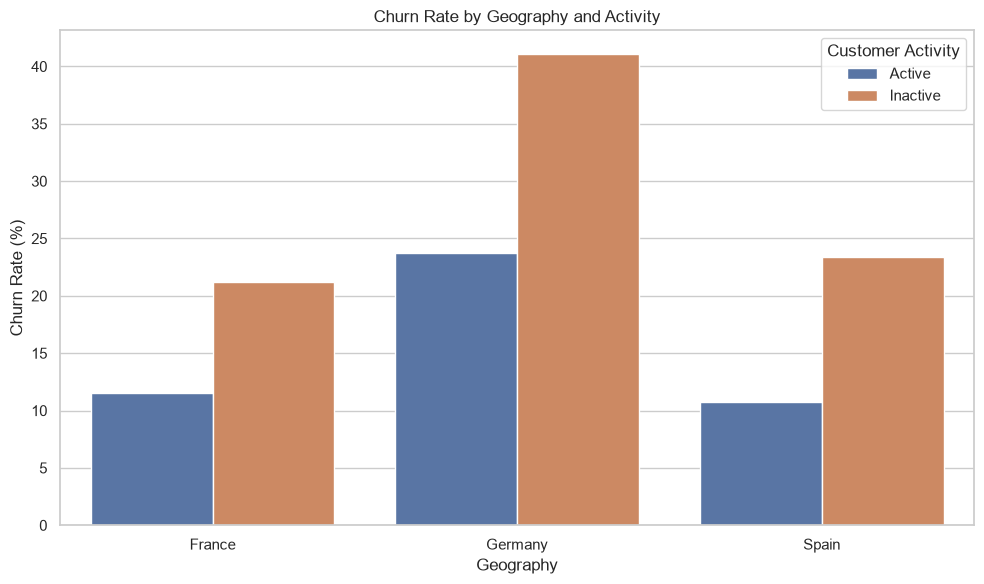

In [37]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=geo_activity,
    x="Geography",
    y="Churn_Rate",
    hue="Active_Label"
)
plt.title("Churn Rate by Geography and Activity")
plt.xlabel("Geography")
plt.ylabel("Churn Rate (%)")
plt.legend(title="Customer Activity")
plt.tight_layout()
plt.show()

## 30. Automated business insight summary

In [38]:
overall_churn = analysis_df["Exited"].mean() * 100
highest_geo = geo_churn.idxmax()
highest_geo_rate = geo_churn.max()

highest_age_group = age_churn.idxmax()
highest_age_rate = age_churn.max()

highest_card_type = card_type_summary["Churn_Rate"].idxmax()
highest_card_rate = card_type_summary["Churn_Rate"].max()

inactive_rate = (
    analysis_df.loc[analysis_df["Active_Label"] == "Inactive", "Exited"].mean() * 100
)
active_rate = (
    analysis_df.loc[analysis_df["Active_Label"] == "Active", "Exited"].mean() * 100
)

print("KEY FINDINGS")
print("-" * 60)
print(f"Overall churn rate: {overall_churn:.2f}%")
print(f"Highest-churn geography: {highest_geo} ({highest_geo_rate:.2f}%)")
print(f"Highest-churn age group: {highest_age_group} ({highest_age_rate:.2f}%)")
print(f"Highest-churn card type: {highest_card_type} ({highest_card_rate:.2f}%)")
print(f"Inactive customer churn rate: {inactive_rate:.2f}%")
print(f"Active customer churn rate: {active_rate:.2f}%")

KEY FINDINGS
------------------------------------------------------------
Overall churn rate: 20.38%
Highest-churn geography: Germany (32.44%)
Highest-churn age group: 46-55 (50.57%)
Highest-churn card type: DIAMOND (21.78%)
Inactive customer churn rate: 26.87%
Active customer churn rate: 14.27%
